Dataset cargado: 1460 filas, 12 columnas

===== ANALISIS EXPLORATORIO =====
Valores nulos totales: 0

Estadisticas de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Variables predictoras finales: 10

===== METRICAS MODELO COMPLETO =====
MAE  : 23,631.23
RMSE : 37,698.88
R2   : 0.7747 (77.47% de varianza explicada)
MAPE : 14.62%


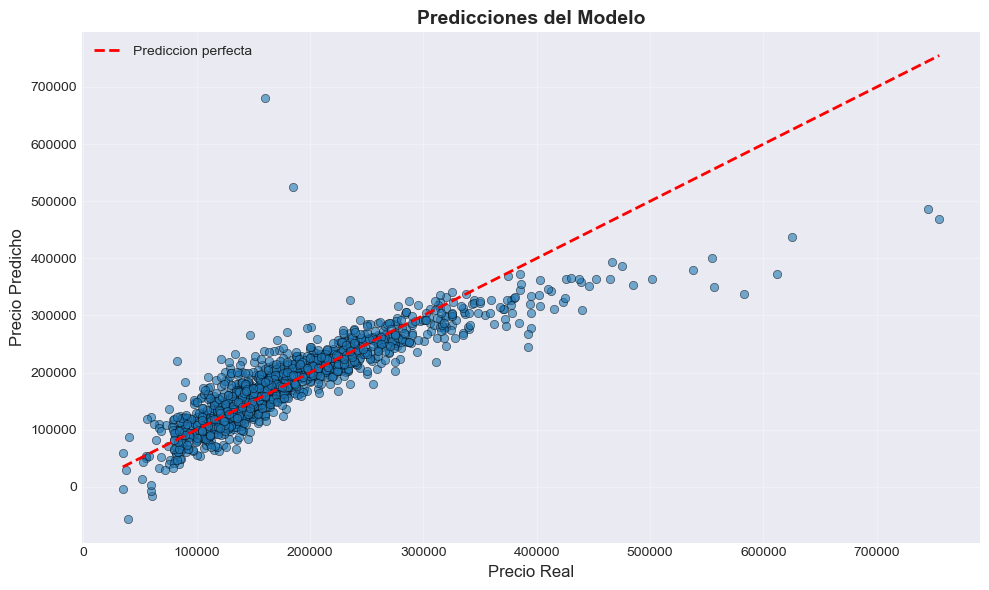

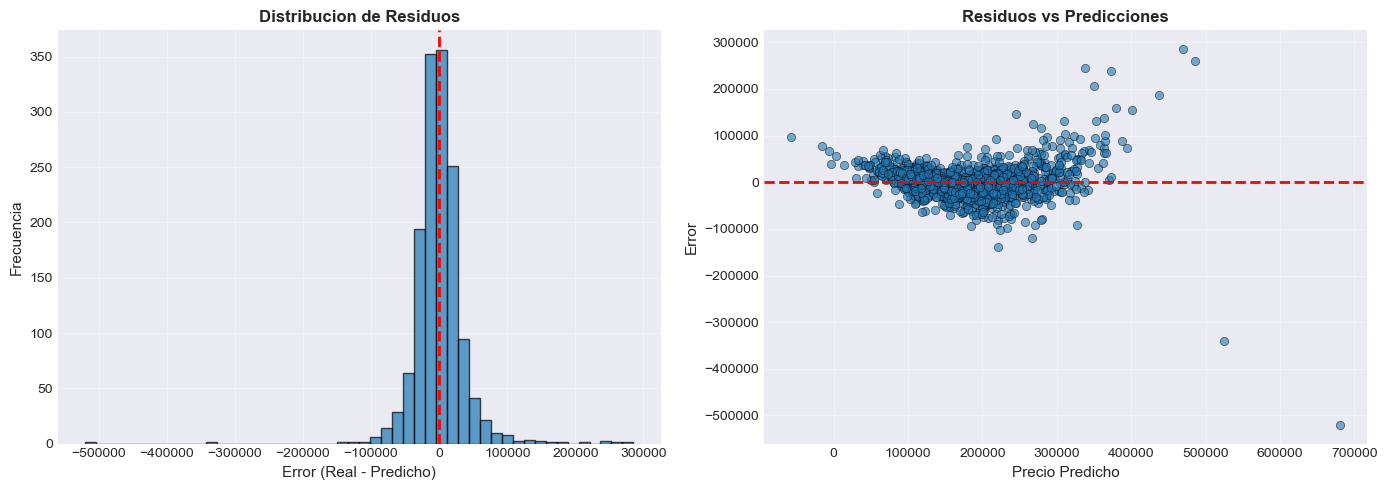


===== TOP 15 VARIABLES MAS INFLUYENTES =====
 1. OverallQual               : + 24,810.71
 2. GarageCars                : + 16,082.35
 3. FullBath                  : + 5,536.21
 4. YearBuilt                 : - 53.83
 5. GrLivArea                 : + 38.57
 6. BsmtFinSF1                : + 21.78
 7. TotalBsmtSF               : + 13.82
 8. GarageArea                : + 6.93
 9. 1stFlrSF                  : + 6.41
10. LotArea                   : + 0.50


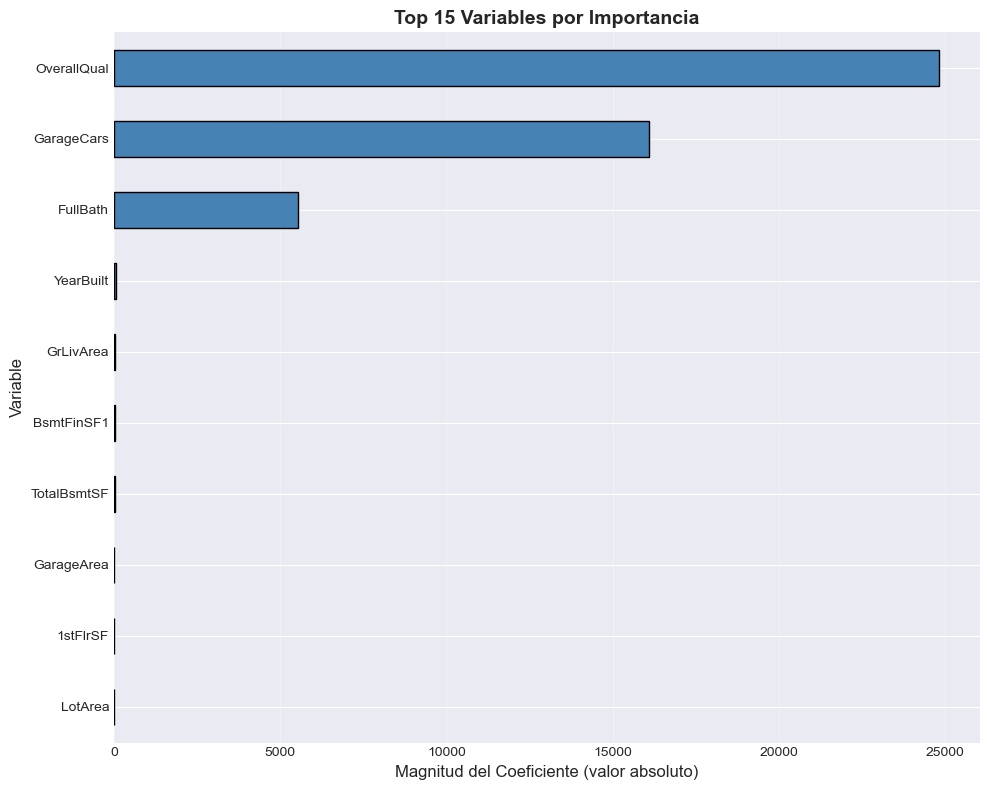


VALIDACION CON DATOS NO VISTOS
Datos de entrenamiento: 1168 muestras
Datos de prueba: 292 muestras

===== METRICAS ENTRENAMIENTO =====
MAE  : 23,592.21
RMSE : 37,448.34
R2   : 0.7649 (76.49% de varianza explicada)
MAPE : 14.42%

===== METRICAS PRUEBA =====
MAE  : 24,678.35
RMSE : 39,191.91
R2   : 0.7997 (79.97% de varianza explicada)
MAPE : 15.35%

===== COMPARACION TRAIN VS TEST =====
R2 Train: 0.7649
R2 Test : 0.7997
Diferencia: 0.0349
Interpretacion: Buen ajuste, el modelo generaliza bien


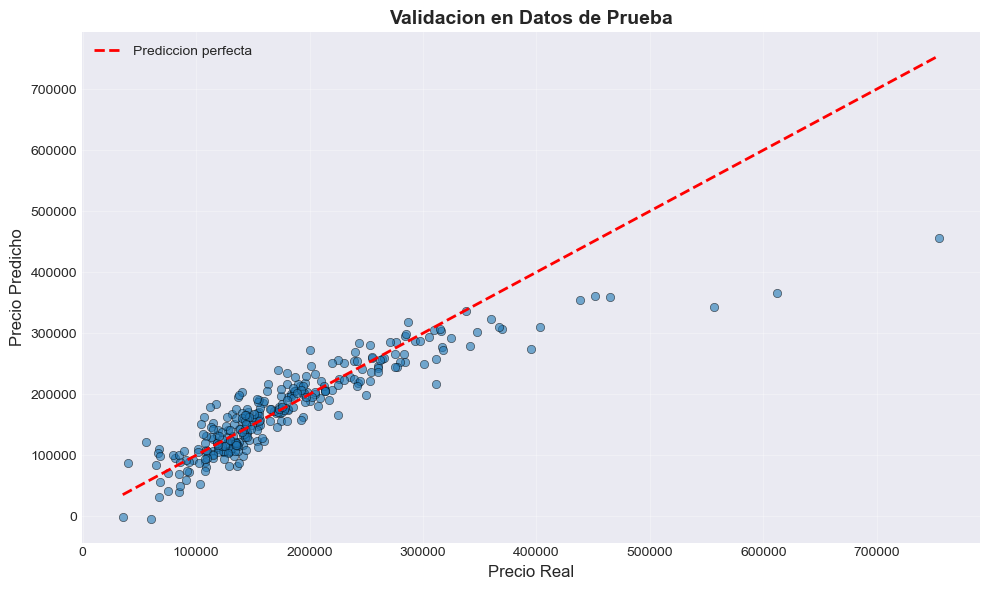


MODELO CON VARIABLES ESTANDARIZADAS

===== METRICAS ESTANDARIZADO =====
MAE  : 181,627.72
RMSE : 184,657.91
R2   : -4.4066 (-440.66% de varianza explicada)
MAPE : 116.15%

Nota: La estandarizacion permite comparar la importancia relativa
de variables que originalmente tienen diferentes escalas.

===== TOP 10 MAYORES ERRORES =====

 Index         Real     Predicho        Error    Error %
------------------------------------------------------------
  1298      160,000      679,982     -519,982     325.0%
   523      184,750      524,099     -339,349     183.7%
   691      755,000      469,733      285,267      37.8%
  1182      745,000      485,807      259,193      34.8%
   803      582,933      337,982      244,951      42.0%
   898      611,657      372,789      238,868      39.1%
  1046      556,581      349,339      207,242      37.2%
  1169      625,000      437,498      187,502      30.0%
   769      538,000      378,953      159,047      29.6%
   440      555,000      400,980   

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ======================================================
# CONFIGURACION INICIAL
# ======================================================
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# ======================================================
# 1. CARGA Y EXPLORACION DE DATOS
# ======================================================
def cargar_datos(ruta):
    """
    Carga el dataset y realiza validaciones basicas.
    """
    try:
        df = pd.read_excel(ruta)
        print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
        return df
    except FileNotFoundError:
        print(f"Error: No se encontro el archivo en {ruta}")
        return None
    except Exception as e:
        print(f"Error al cargar datos: {e}")
        return None

RUTA_TRAIN = r"C:\Users\Camil\Downloads\train.xlsx"
df = cargar_datos(RUTA_TRAIN)

if df is None:
    raise SystemExit("No se pudo cargar el dataset")

TARGET = "SalePrice"

# Analisis exploratorio basico
print("\n===== ANALISIS EXPLORATORIO =====")
print(f"Valores nulos totales: {df.isnull().sum().sum()}")
print(f"\nEstadisticas de {TARGET}:")
print(df[TARGET].describe())

# ======================================================
# 2. PREPARACION DE DATOS
# ======================================================
def preparar_datos(df, target):
    """
    Separa variables predictoras y objetivo.
    Elimina columnas no numericas y la columna ID.
    """
    X = df.drop(columns=[target])
    y = df[target].values
    
    if "Id" in X.columns:
        X = X.drop(columns=["Id"])
    
    X_numeric = X.select_dtypes(include=[np.number])
    
    cols_eliminadas = set(X.columns) - set(X_numeric.columns)
    if cols_eliminadas:
        print(f"\nColumnas no numericas eliminadas: {len(cols_eliminadas)}")
    
    return X_numeric, y

X, y = preparar_datos(df, TARGET)
X_mat = X.values

print(f"\nVariables predictoras finales: {X.shape[1]}")

# ======================================================
# 3. MODELO POR MINIMOS CUADRADOS
# ======================================================
def minimos_cuadrados(A, b):
    """
    Resuelve el sistema de ecuaciones normales: x = (A'A)^-1 A'b
    Usa pseudoinversa para mayor estabilidad numerica.
    """
    return np.linalg.pinv(A) @ b

def entrenar_modelo(X, y):
    """
    Entrena el modelo y retorna coeficientes y predicciones.
    """
    coef = minimos_cuadrados(X, y)
    y_pred = X @ coef
    return coef, y_pred

coef, y_pred = entrenar_modelo(X_mat, y)

# ======================================================
# 4. METRICAS DE EVALUACION
# ======================================================
def calcular_metricas(y_real, y_pred, nombre=""):
    """
    Calcula y muestra metricas de error del modelo.
    """
    error = y_real - y_pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2 = 1 - ss_res / ss_tot
    
    mape = np.mean(np.abs(error / y_real)) * 100
    
    print(f"\n===== METRICAS {nombre.upper()} =====")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R2   : {r2:.4f} ({r2*100:.2f}% de varianza explicada)")
    print(f"MAPE : {mape:.2f}%")
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

metricas_train = calcular_metricas(y, y_pred, "MODELO COMPLETO")

# ======================================================
# 5. VISUALIZACIONES
# ======================================================
def plot_predicciones(y_real, y_pred, titulo="Predicciones del Modelo"):
    """
    Grafico de dispersion: valores reales vs predichos.
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(y_real, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    min_val, max_val = y_real.min(), y_real.max()
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', 
             linewidth=2, label='Prediccion perfecta')
    
    plt.xlabel("Precio Real", fontsize=12)
    plt.ylabel("Precio Predicho", fontsize=12)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_residuos(y_real, y_pred):
    """
    Graficos de analisis de residuos.
    """
    error = y_real - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(error, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel("Error (Real - Predicho)", fontsize=11)
    axes[0].set_ylabel("Frecuencia", fontsize=11)
    axes[0].set_title("Distribucion de Residuos", fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(y_pred, error, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel("Precio Predicho", fontsize=11)
    axes[1].set_ylabel("Error", fontsize=11)
    axes[1].set_title("Residuos vs Predicciones", fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_predicciones(y, y_pred)
plot_residuos(y, y_pred)

# ======================================================
# 6. IMPORTANCIA DE VARIABLES
# ======================================================
def analizar_importancia(coef, nombres_columnas, top_n=15):
    """
    Analiza y visualiza la importancia de las variables.
    """
    coef_series = pd.Series(coef, index=nombres_columnas)
    coef_abs = coef_series.abs().sort_values(ascending=False)
    
    print(f"\n===== TOP {top_n} VARIABLES MAS INFLUYENTES =====")
    for i, (var, valor) in enumerate(coef_abs.head(top_n).items(), 1):
        signo = "+" if coef_series[var] > 0 else "-"
        print(f"{i:2d}. {var:25s} : {signo} {valor:,.2f}")
    
    plt.figure(figsize=(10, 8))
    coef_abs.head(top_n).sort_values().plot(kind="barh", color='steelblue', 
                                             edgecolor='black')
    plt.xlabel("Magnitud del Coeficiente (valor absoluto)", fontsize=12)
    plt.ylabel("Variable", fontsize=12)
    plt.title(f"Top {top_n} Variables por Importancia", 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    return coef_abs

importancia = analizar_importancia(coef, X.columns)

# ======================================================
# 7. VALIDACION CRUZADA (TRAIN/TEST)
# ======================================================
print("\n" + "="*50)
print("VALIDACION CON DATOS NO VISTOS")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_mat, y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")

coef_train, y_train_pred = entrenar_modelo(X_train, y_train)
y_test_pred = X_test @ coef_train

metricas_train_split = calcular_metricas(y_train, y_train_pred, "ENTRENAMIENTO")
metricas_test = calcular_metricas(y_test, y_test_pred, "PRUEBA")

print("\n===== COMPARACION TRAIN VS TEST =====")
print(f"R2 Train: {metricas_train_split['R2']:.4f}")
print(f"R2 Test : {metricas_test['R2']:.4f}")
diferencia = abs(metricas_train_split['R2'] - metricas_test['R2'])
print(f"Diferencia: {diferencia:.4f}")

if diferencia < 0.05:
    print("Interpretacion: Buen ajuste, el modelo generaliza bien")
elif diferencia < 0.15:
    print("Interpretacion: Ajuste moderado, ligero sobreajuste")
else:
    print("Interpretacion: Posible sobreajuste, gran diferencia entre train y test")

plot_predicciones(y_test, y_test_pred, "Validacion en Datos de Prueba")

# ======================================================
# 8. MODELO CON ESTANDARIZACION
# ======================================================
print("\n" + "="*50)
print("MODELO CON VARIABLES ESTANDARIZADAS")
print("="*50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mat)

coef_scaled, y_pred_scaled = entrenar_modelo(X_scaled, y)
metricas_scaled = calcular_metricas(y, y_pred_scaled, "ESTANDARIZADO")

print("\nNota: La estandarizacion permite comparar la importancia relativa")
print("de variables que originalmente tienen diferentes escalas.")

# ======================================================
# 9. ANALISIS DE ERRORES CRITICOS
# ======================================================
def analizar_errores_criticos(df_original, y_real, y_pred, top_n=10):
    """
    Identifica y analiza las predicciones con mayores errores.
    """
    df_analisis = df_original.copy()
    df_analisis["Precio_Real"] = y_real
    df_analisis["Precio_Predicho"] = y_pred
    df_analisis["Error"] = y_real - y_pred
    df_analisis["Error_Abs"] = np.abs(df_analisis["Error"])
    df_analisis["Error_Pct"] = (df_analisis["Error_Abs"] / y_real) * 100
    
    print(f"\n===== TOP {top_n} MAYORES ERRORES =====")
    errores_top = df_analisis.nlargest(top_n, "Error_Abs")
    
    print("\n{:>6} {:>12} {:>12} {:>12} {:>10}".format(
        "Index", "Real", "Predicho", "Error", "Error %"))
    print("-" * 60)
    
    for idx, row in errores_top.iterrows():
        print("{:>6} {:>12,.0f} {:>12,.0f} {:>12,.0f} {:>9.1f}%".format(
            idx,
            row["Precio_Real"],
            row["Precio_Predicho"],
            row["Error"],
            row["Error_Pct"]
        ))
    
    return df_analisis

df_errores = analizar_errores_criticos(df, y, y_pred)

# ======================================================
# 10. RESUMEN FINAL
# ======================================================
print("\n" + "="*50)
print("RESUMEN FINAL DEL MODELO")
print("="*50)
print(f"Variables utilizadas: {X.shape[1]}")
print(f"Muestras de entrenamiento: {len(y)}")
print(f"\nRendimiento general:")
print(f"  R2 = {metricas_train['R2']:.4f}")
print(f"  MAE = {metricas_train['MAE']:,.2f}")
print(f"  RMSE = {metricas_train['RMSE']:,.2f}")
print(f"\nRendimiento en validacion:")
print(f"  R2 Test = {metricas_test['R2']:.4f}")
print("\nAnalisis completado")